# Batch simulation and optimization
A major advantage with the Python API is the ability to run simulations with different parameter sets in parallel (i.e. in "batches"). One useful application of this is to run several simulations where a single parameter (or group of parameters) is changing.

In this tutorial, we will introduce how to use the `BatchSimulate` to run a parameter sweep, and then visualize the resulting change in simulation output.

## 1. Loading and visualizing EEG ERP data

Here we are going to focus on an artificial example from [Tolley et al. 2026](https://www.jove.com/t/70618/a-protocol-for-uncovering-neural-mechanisms-neurotherapeutic-effects). The context is we are fitting a model to ERP waveforms measured before and after a hypothetical treatment which alters brain activity.

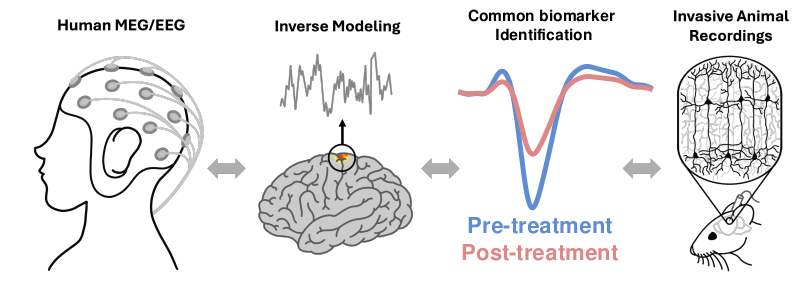

Uncomment this block using (shortcut is `Ctrl+A` and `Ctrl+/`) if you are running Google CoLab

In [ ]:
# !pip install hnn_core[opt]
# !git clone https://github.com/ntolley/hnn-workshop-materials/
# %cd hnn-workshop-materials/
# !git checkout nsg_optimization

In [ ]:
from hnn_core import read_dipole
import matplotlib.pyplot as plt

# Load in pre-treat and post treatment waveforms

pre_dpl_data = read_dipole('jove_data/pre-treatment.txt')
post_dpl_data = read_dipole('jove_data/post-treatment.txt')


# Useful plotting defaults used throughout
fontsize = 15
linewidth = 2
smooth = 30
scale_factor = 1000
pre_color, post_color = 'C0', 'C3'

# Plot waveforms to compare
plt.figure(figsize=(6,4))
plt.plot(pre_dpl_data.times, pre_dpl_data.data['agg'], linewidth=linewidth, color=pre_color, label='Pre-treatment')
plt.plot(post_dpl_data.times, post_dpl_data.data['agg'], linewidth=linewidth, color=post_color, label='Post-treatment')

plt.xlabel('Time (ms)', fontsize=fontsize)
plt.ylabel('Dipole (nAm)', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.title('Recorded EEG ERPs', fontsize=fontsize)

## 2. Run the "pre-treatment" simulation

We provide a set of drive parameters that have been optimized to the pre-treatment waveform. In the following section, we will explore some hypotheses on sets of parameters that can explain the change to the post-treatment waveform.

In [ ]:
from hnn_core import simulate_dipole, read_network_configuration

dt= 0.5
tstop = 250
verbose = False

# Load in pre-treatment network configuration
net = read_network_configuration('jove_data/pre-treatment_optimized_config.json')
pre_dpl = simulate_dipole(net, dt=dt, tstop=tstop, verbose=verbose)

In [ ]:
plot_data = pre_dpl[0].copy().smooth(smooth).scale(scale_factor).data['agg']
times = net.cell_response.times

plt.figure(figsize=(6,4))
plt.plot(times, plot_data, linewidth=linewidth, label='Optimized sim', color='k')
plt.plot(pre_dpl_data.times, pre_dpl_data.data['agg'], linewidth=linewidth, color=pre_color, label='Pre-treatment')
plt.plot(post_dpl_data.times, post_dpl_data.data['agg'], linewidth=linewidth, color=post_color, label='Post-treatment')
plt.xlabel('Time (ms)', fontsize=fontsize)
plt.ylabel('Dipole (nAm)', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.title('Optimized Pre-treatment ERP', fontsize=fontsize)


## 3. Define function to update model parameters
To run a batch simulation, we need to define a function which updates the parameters we care about in the network.

Below, we create a `set_params` function which updates the following parameters:
* `Proximal synchronization`: Standard deviation of the first proximal drive
* `Dendritic Km`: Potassium channel conductance in pyramidal neuron dendrites
* `Inhibitory gain`: Conductance of all GABAb synapses in the network
* `Distal gain`: Conductance of all distal drive synapses in the network

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from hnn_core.batch_simulate import BatchSimulate
from hnn_core import pick_connection

# The number of cores may need modifying depending on your current machine.
n_jobs = 4

def set_params(param_values, net):
    """
    Set parameters for the network drives.

    Parameters
    ----------
    param_values : dict
        Dictionary of parameter values.
    net : instance of Network
        Network to be updated
    """

    # Proximal synchronization
    net.external_drives['evprox1']['dynamics']['sigma'] *= param_values.get('ff_sync_scale', 1)

    # Dendritic Km
    for sec_name, sec in net.cell_types['L5_pyramidal']['cell_object'].sections.items():
        if sec_name != 'soma':
            sec.mechs['km']['gbar_km'] *= (10 ** param_values.get('km_scale', 0))

    # Inhibitory gain
    conn_indices = pick_connection(net, receptor=['gabab'])
    for conn_idx in conn_indices:
        net.connectivity[conn_idx]['nc_dict']['A_weight'] *= 10 ** param_values.get('inh_gain_scale', 0)

    # Distal gain
    conn_indices = pick_connection(net, src_gids='evdist1')
    for conn_idx in conn_indices:
        net.connectivity[conn_idx]['nc_dict']['A_weight'] *= 10 ** param_values.get('fb_gain_scale', 0)

Next we define which parameters we want to sweet over. Note above that rather than specifying parameter values explicitly, `set_params()` multiplies the current value of the network by what is found in `param_values`.

*Exercise* : uncomment one of the lines below to run a parameter sweep for one of 4 possible parameters.

In [ ]:
num_sims = 8

param_values = {
    # 'ff_sync_scale': np.linspace(0, 5, num_sims),
    'km_scale': np.linspace(-1, 1, num_sims),
    # 'inh_gain_scale': np.linspace(-1, 1, num_sims),
    # 'fb_gain_scale': np.linspace(-1, 1, num_sims)
}

print(param_values)

## 4. Run simulations in parallel with `BatchSimulate`
Lastly we set up the `BatchSimulate` class to run a parameter sweep. This class is useful for managing parameter sweeps because it provides options for storing simulation outputs in an organized formats.

It additionally can be configured to write simulations to files when the number of simulations run is so large the data does not fit on your computer's RAM.

In [ ]:
# Instantiate the BatchSimulate object to handle running and saving large trainng batches
batch_simulation = BatchSimulate(net=net,
                                 set_params=set_params,
                                 tstop=tstop,
                                 dt=dt)

# Simulate the samples from the prior distribution and save the results.
results = batch_simulation.run(param_values,
                         n_jobs=n_jobs,
                         combinations=False,
                         backend='loky',
                         verbose=verbose)

## 5. Visualizing parameter sweeps from batch simulations
To help visualize how waveforms change with different values of parameters, we can use a color gradient.

The `LinearSegementedColormap` from `matplotlib` allows us to make plots where the line color corresponds to the value of the parameter run. Below black is the smallest value used, and red is the largest value used.

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

dpl_data = list()
for res in results['simulated_data'][0]:
    data = res['dpl'][0].copy().smooth(smooth).scale(scale_factor).data['agg']
    dpl_data.append(data)

colors = ['k', 'r'] # first color is black, last is red
cmap = LinearSegmentedColormap.from_list( "Custom", colors)

plt.figure(figsize=(6,4))
for sim_idx in range(num_sims):
    sweep_color = cmap(sim_idx / num_sims)
    plt.plot(times, dpl_data[sim_idx], linewidth=1.5, color=sweep_color)

plt.xlabel('Time (ms)', fontsize=fontsize)
plt.ylabel('Dipole (nAm)', fontsize=fontsize)
plt.title('Parameter Sweep', fontsize=fontsize)

## 6. Exercise: Try a different parameter to sweep over
Above we tried simulations where the conductance of dendritic potassium channels was modified. Return the block in Step 3 where `param_values` is defined and uncomment a different parameter.